In [3]:
import os
import joblib
import torch

MODEL_DIR =  r"C:\mutation\models"   # change if models are in another folder

files = os.listdir(MODEL_DIR)

print("Found models:\n", files)

# -----------------------------
# 🔹 1. Function for SKLEARN MODELS
# -----------------------------
def inspect_sklearn_model(model, name):
    print(f"\n===== {name} =====")
    print("Type:", type(model))

    # Parameters
    if hasattr(model, "get_params"):
        print("\nParameters:")
        for k, v in model.get_params().items():
            print(f"{k}: {v}")

    # Feature importance (if exists)
    if hasattr(model, "feature_importances_"):
        print("\nFeature Importances (Top 10):")
        print(model.feature_importances_[:10])

    # Coefficients (for linear models)
    if hasattr(model, "coef_"):
        print("\nCoefficients:")
        print(model.coef_[:1])

# -----------------------------
# 🔹 2. Function for TORCH MODELS
# -----------------------------
def inspect_torch_model(path, name):
    print(f"\n===== {name} =====")
    
    model = torch.load(path, map_location="cpu")

    print("Type:", type(model))

    if hasattr(model, "state_dict"):
        print("\nLayers & Parameters:")
        for k, v in model.state_dict().items():
            print(f"{k} -> shape {tuple(v.shape)}")

# -----------------------------
# 🔹 3. Loop through files
# -----------------------------
for file in files:
    path = os.path.join(MODEL_DIR, file)

    try:
        if file.endswith(".pkl"):
            model = joblib.load(path)
            inspect_sklearn_model(model, file)

        elif file.endswith(".pt"):
            inspect_torch_model(path, file)

    except Exception as e:
        print(f"\nError loading {file}: {e}")

Found models:
 ['feature_scaler.pkl', 'gene_gat_model.pt', 'gene_gnn_model.pt', 'gradient_boost.pkl', 'logistic_regression.pkl', 'random_forest.pkl', 'stacking_ensemble.pkl', 'svm.pkl', 'xgboost.pkl']

===== feature_scaler.pkl =====
Type: <class 'sklearn.preprocessing._data.StandardScaler'>

Parameters:
copy: True
with_mean: True
with_std: True

===== gene_gat_model.pt =====
Type: <class 'collections.OrderedDict'>

===== gene_gnn_model.pt =====
Type: <class 'collections.OrderedDict'>

===== gradient_boost.pkl =====
Type: <class 'sklearn.ensemble._gb.GradientBoostingClassifier'>

Parameters:
ccp_alpha: 0.0
criterion: friedman_mse
init: None
learning_rate: 0.1
loss: log_loss
max_depth: 7
max_features: None
max_leaf_nodes: None
min_impurity_decrease: 0.0
min_samples_leaf: 1
min_samples_split: 2
min_weight_fraction_leaf: 0.0
n_estimators: 600
n_iter_no_change: None
random_state: 42
subsample: 0.8
tol: 0.0001
validation_fraction: 0.1
verbose: 0
warm_start: False

Feature Importances (Top 10

In [7]:
# 0. SETUP
# ==========================================
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import torch
import gc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import plotly.graph_objects as go

from sklearn.preprocessing import StandardScaler
from torch_geometric.data import Data
from torch_geometric.utils import to_undirected, add_self_loops, k_hop_subgraph
from torch_geometric.nn import GATv2Conv
import torch.nn.functional as F
from torch_geometric.explain import Explainer, GNNExplainer

# ==========================================
# GPU CHECK
# ==========================================
if not torch.cuda.is_available():
    raise RuntimeError("CUDA not available")

device = torch.device("cuda:0")
print("GPU:", torch.cuda.get_device_name(0))

def clean_gpu():
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

GPU: NVIDIA GeForce RTX 3060 Laptop GPU


In [8]:
# ==========================================
# 1. LOAD DATA (IMPORTANT: SAME AS TRAINING)
# ==========================================
BASE_DATA_DIR = r"C:\mutation\data\processed"
BASE_MODEL_DIR = r"C:\mutation\models"
TARGET_GENE = "BRCA1"

features_df = pd.read_csv(f"{BASE_DATA_DIR}/final_gene_features.csv")
edges_df = pd.read_csv(f"{BASE_DATA_DIR}/final_edge_list.csv")

# 🔥 MUST MATCH TRAINING
GNN_DROP = {
    "GeneSymbol","description","label",
    "pathogenic_variants","pathogenic",
    "neighbor_pathogenic_ratio","mutation_network_score",
    "rare_network_score","gene_degree",
    "clustering_coefficient","pagerank","betweenness_centrality"
}

gnn_cols = [c for c in features_df.columns
            if c not in GNN_DROP and pd.api.types.is_numeric_dtype(features_df[c])]

print("Feature count:", len(gnn_cols))  # should be SAME as training

Feature count: 38


In [9]:
# ==========================================
# 2. FEATURE PROCESSING
# ==========================================
scaler = StandardScaler()
X = scaler.fit_transform(features_df[gnn_cols].values.astype(np.float32))

genes = features_df["GeneSymbol"].tolist()
g2i = {g:i for i,g in enumerate(genes)}
i2g = {i:g for i,g in enumerate(genes)}

target_node_idx = g2i[TARGET_GENE]

# ==========================================
# 3. GRAPH BUILD
# ==========================================
valid_edges = [[g2i[r.gene1], g2i[r.gene2]]
               for r in edges_df.itertuples()
               if r.gene1 in g2i and r.gene2 in g2i]

edge_index = torch.tensor(valid_edges).t().contiguous()
edge_index = to_undirected(edge_index)
edge_index, _ = add_self_loops(edge_index, num_nodes=len(genes))

graph_data = Data(
    x=torch.tensor(X, dtype=torch.float),
    edge_index=edge_index
).to(device)


In [10]:
# ==========================================
# 4. MODEL (EXACT SAME AS TRAINING)
# ==========================================
class GeneGAT(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim=128, heads=8):
        super().__init__()
        self.conv1 = GATv2Conv(input_dim, hidden_dim, heads=heads, dropout=0.3)
        self.ln1   = torch.nn.LayerNorm(hidden_dim * heads)
        self.conv2 = GATv2Conv(hidden_dim * heads, 2, heads=1, concat=False)
        self.skip  = torch.nn.Linear(input_dim, hidden_dim * heads)

    def forward(self, x, edge_index):
        x1 = self.conv1(x, edge_index) + self.skip(x)
        x1 = F.elu(self.ln1(x1))
        x1 = F.dropout(x1, p=0.4, training=self.training)
        return self.conv2(x1, edge_index)

# 🔥 AUTO MATCH INPUT DIMENSION
model = GeneGAT(graph_data.x.shape[1]).to(device)

model.load_state_dict(
    torch.load(f"{BASE_MODEL_DIR}/gene_gat_model.pt", map_location=device)
)

model.eval()
clean_gpu()

In [11]:
# ==========================================
# 5. EXPLAINER
# ==========================================
clean_gpu()

explainer = Explainer(
    model=model,
    algorithm=GNNExplainer(epochs=50),
    explanation_type='model',
    node_mask_type='attributes',
    edge_mask_type='object',
    model_config=dict(
        mode='multiclass_classification',
        task_level='node',
        return_type='raw',
    ),
)

explanation = explainer(graph_data.x, graph_data.edge_index, index=target_node_idx)

node_mask = explanation.node_mask.cpu().numpy()
edge_mask = explanation.edge_mask.cpu().numpy()

clean_gpu()


In [12]:
# ==========================================
# 6. SUBGRAPH (FIXES YOUR PREVIOUS ERROR)
# ==========================================
subset, sub_edge_index, mapping, edge_mask_indices = k_hop_subgraph(
    target_node_idx, num_hops=1,
    edge_index=graph_data.edge_index,
    relabel_nodes=True
)

subset_genes = [i2g[idx.item()] for idx in subset]
sub_edge_weights = edge_mask[edge_mask_indices.cpu().numpy()]

In [13]:
# ==========================================
# 7. FILTER GRAPH (IMPORTANT)
# ==========================================
top_k = 20

edges = []
for i in range(sub_edge_index.shape[1]):
    src = subset_genes[sub_edge_index[0, i].item()]
    dst = subset_genes[sub_edge_index[1, i].item()]
    w = sub_edge_weights[i]

    if src != dst and w > 0.1:
        edges.append((src, dst, w))

edges = sorted(edges, key=lambda x: x[2], reverse=True)[:top_k]

G = nx.Graph()
for u,v,w in edges:
    G.add_edge(u,v,weight=w)

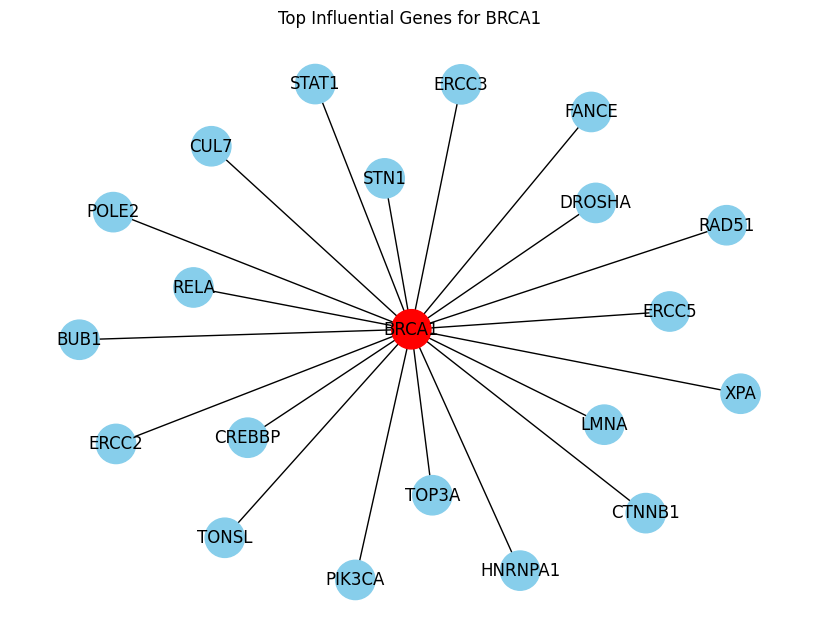

In [14]:
# ==========================================
# 8. 2D VISUALIZATION
# ==========================================
plt.figure(figsize=(8,6))
pos = nx.spring_layout(G, k=0.8, seed=42)

nx.draw(
    G, pos,
    node_color=['red' if n==TARGET_GENE else 'skyblue' for n in G.nodes()],
    node_size=800,
    with_labels=True
)

plt.title(f"Top Influential Genes for {TARGET_GENE}")
plt.show()

In [15]:
# ==========================================
# 9. 3D VISUALIZATION (INTERACTIVE)
# ==========================================
pos_3d = nx.spring_layout(G, dim=3, seed=42)

edge_x, edge_y, edge_z = [], [], []
for e in G.edges():
    x0,y0,z0 = pos_3d[e[0]]
    x1,y1,z1 = pos_3d[e[1]]
    edge_x += [x0,x1,None]
    edge_y += [y0,y1,None]
    edge_z += [z0,z1,None]

node_x = [pos_3d[n][0] for n in G.nodes()]
node_y = [pos_3d[n][1] for n in G.nodes()]
node_z = [pos_3d[n][2] for n in G.nodes()]

fig = go.Figure()

fig.add_trace(go.Scatter3d(
    x=edge_x, y=edge_y, z=edge_z,
    mode='lines',
    line=dict(width=2, color='gray')
))

fig.add_trace(go.Scatter3d(
    x=node_x, y=node_y, z=node_z,
    mode='markers+text',
    text=list(G.nodes()),
    marker=dict(
        size=8,
        color=['red' if n==TARGET_GENE else 'blue' for n in G.nodes()]
    )
))

fig.update_layout(title="3D Gene Interaction Graph")
fig.show()